<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi
</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 5</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>


<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 5</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- Aufgabe 05_01
- **Aufgabe 05_02**
- Aufgabe 05_03

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Pseudo-inverse 05_02</td>


## Pseudoinverse (Moore–Penrose) of a matrix

Die Pseudoinverse einer Matrix ist eine Verallgemeinerung der üblichen Inversen einer (nicht-singulären) quadratischen Matrix.
Im folgenden werden wir Sie als $A^+$ bezeichnen.
Sie kann aus der SVD berechnet werden, die Sie schon kennen gelernt haben. 
Ausgehend von einer generischen $n\times m$ Matrix $A$ können wir die vollständige SVD berechnen (die Anzahl der Singulärwerte
welche ungleich Null sind, ist äquivalent zum Rang der Matrix, siehe Skript der Vorlesung):
$$
A = U
\begin{pmatrix}
\Sigma & \dots & 0 \\
\vdots & \ddots & 0 \\
0 & \dots & 0
\end{pmatrix} V^{T}
$$
Man kann die Pseudo-Inverse wie folgt konstruieren:
$$
A^+ = V
\begin{pmatrix}
\Sigma^{-1} & \dots & 0 \\
\vdots & \ddots & 0 \\
0 & \dots & 0
\end{pmatrix} U^{T} \ .
$$

## a) Konstruktion der Pseudoinverse
Definieren Sie eine zufällige $5\times 4$ Matrix $A$ und konstruieren Sie eine Funktion zur Berechnung der Pseudominversen.
Zeigen Sie danach, dass die folgenden Beziehungen erfüllt sind:


$$
A A^+ A = A \\
A^+ A A^+ = A^+
$$

Sie können das Symbol `≈` (`isapprox`) verwenden, um die Matrizen zu vergleichen.

In [70]:
using LinearAlgebra

function pseudo_inverse(A)
    U, sigma, V = svd(A)
    S = Diagonal(sigma)
    pseudo_inv = V * inv(S) * U'
    return pseudo_inv
end



pseudo_inverse (generic function with 1 method)

In [72]:
A = rand(5, 4)
A_p = pseudo_inverse(A)

4×5 Matrix{Float64}:
 -2.21812    -2.40465    3.05112    0.406205  -0.0558551
  0.707714    0.461685  -0.448606  -1.00507    1.37063
  0.0285137   1.45425   -0.423111   0.145462   0.300781
  0.879343   -0.685654  -0.204363   0.800622  -1.21949

In [73]:
A_p ≈ pinv(A)



true

Zeigen Sie, dass die Pseudo-Inverse einer $n\times m$ Matrix $A$ mit vollem Spaltenrang ($n \ge m$) die *linke Inverse* $A^+ A = I_m$ ist.

In [74]:
A = rand(7 , 4)
pinv(A) * A ≈ I(4)

true

Zeigen Sie, dass die Pseudoinverse einer $n\times m$ Matrix $A$ mit vollem Zeilenrang ($m \ge n$) die *rechte Inverse* $A A^+ = I_n$ ist.

In [75]:
A = rand(4, 7)
A * pinv(A) ≈ I(4)

true

Zeigen Sie, dass für eine nicht-singuläre, quadratische Matrix die Pseudo-Inverse **äquivalent** zur Inversen ist.

In [76]:
A = rand(4, 4)
pinv(A) ≈ inv(A)

true

## b) Lineare Systeme mit Hilbert-Matrix
Die Hilbert-Matrix haben Sie in Aufgabe 05_01 kennengelernt. Sie lässt sich aus der folgenden Beziehung konstruieren:
$$
𝐻_{ij}=1/(i+j-1)
$$
und wir haben bereits gezeigt, dass sie ein sehr seltsames numerisches Verhalten hat. 
Definieren Sie wiederum eine Funktion zur Konstruktion einer Hilbert-Matrix in Abhängigkeit von ihrer Dimension. Versuchen Sie dann, das lineare System $Ax=b$ zu lösen, wobei $b$ ein Vektor aus Einsen ist.
Verwenden Sie dazu die oben implementierte Funktion zur Berechnung der Pseudoinversen und $x = A^+ b$.

Berechnen Sie dann den Fehler der Lösung mit Hilfe der Norm $|Ax-b|$. Wie groß ist dieser Fehler für eine Hilbert-Matrix der Dimension $N=20$?

In [81]:
function Hilbert(n)
    H = zeros(Float64, n, n)
    for i in 1:n
        for j in 1:n
            H[i,j] = 1/(i+j-1)
        end
    end
    return H
end 

N = 20

H = Hilbert(N)

b = ones(Float64, N)
x = pinv(H) * b

fehler = norm(H*x - b)

0.0006286810248757246

Warum ist die Lösung so schlecht? 
Versuchen Sie das zu erklären, indem Sie sich die (log) Singulärwerte einer großen Hilbert-Matrix ansehen.

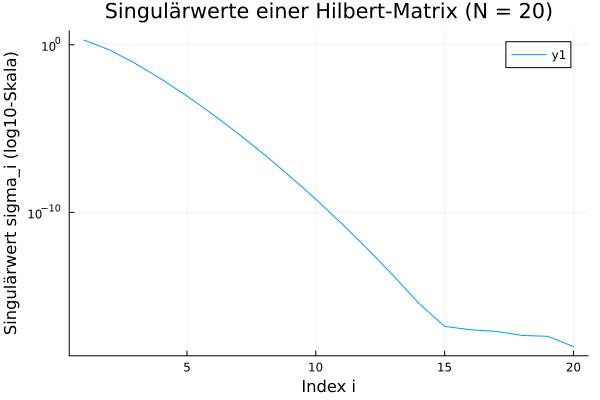

In [95]:
using Plots



N = 20
H = Hilbert(N)
sigma = svdvals(H)

plot(1:N, sigma,
    yscale = :log10,
    title = "Singulärwerte einer Hilbert-Matrix (N = 20)",
    xlabel = "Index i",
    ylabel = "Singulärwert sigma_i (log10-Skala)",)


In [84]:
#Singulärwerte werden extrem klein
#Rundungsfehler bei kleinen Zahlen
#Kehrwert wird gigantisch groß
#deshalb gibt es eine Abbruchtoleranz -> Werte darunter werden auf Null gesetzt
#Dimension wird abgeschnitten

Definieren Sie nun eine neue Funktion zur Berechnung der Pseudoinversen, welche kleine Singulärwerte abschneidet. Berechnen Sie den Fehler der Lösung von demselben linearen Gleichungssystem von oben, wobei Sie diesesmal die ursprüngliche Implementierung
mit der Neuen vergleichen. Tragen Sie den Fehler beider Methoden (logarithmisch) gegen die Größe der Hilbert-Matrix auf und
kommentieren Sie das Ergebnis.

In [91]:
function pseudo_inverse_with_trunc(H,tol=1e-15)

    U, sigma, V = svd(A)
    idx = findfirst(x -> x <= tol, sigma)
    sigma[idx:end] .= 0
    S = Diagonal(sigma)
    sigma_inv = [s > tol ? 1.0 / s : 0.0 for s in sigma]
    pseudo_inv = V * sigma_inv * U'
    return pseudo_inv
end

N_range = 10:2:50
error_no_trunc = Array{Float64}(undef,length(N_range))
error_with_trunc = Array{Float64}(undef,length(N_range))

for (i,N) in enumerate(N_range)
    H = Hilbert(N)
    b = ones(N)
    x = H \ b
    x_no = pinv(H) * b
    error_no_trunc[i] = norm(x - x_no)

    x_with = pseudo_inverse_with_trunc(H,1e-15) * b
    error_with_trunc[i] = norm(x - x_with)
end



MethodError: MethodError: no method matching (::Colon)(::Nothing, ::Int64)
The function `Colon()` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  (::Colon)(::T, ::Any, !Matched::T) where T
   @ Base range.jl:52
  (::Colon)(!Matched::T, ::Real, !Matched::T) where T<:AbstractFloat
   @ Base range.jl:18
  (::Colon)(!Matched::T, ::T, !Matched::T) where T<:Real
   @ Base range.jl:22
  ...


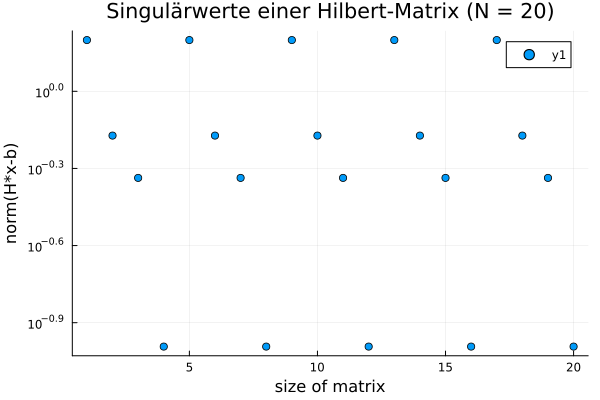

In [86]:
###
### PLOT HERE
###
xlabel!("size of matrix")
ylabel!("norm(H*x-b)")